In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("spam.csv", encoding="latin1")

In [3]:
df.head

<bound method NDFrame.head of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  

In [4]:
df.shape


(5572, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [10]:
df.describe(include="all")

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [8]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [9]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [11]:
df = df.drop(
    columns=[
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4"
    ]
)

In [12]:
df.columns = [
    "Label",
    "Message"
]

In [13]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df = df.drop_duplicates()

In [16]:
df.shape

(5169, 2)

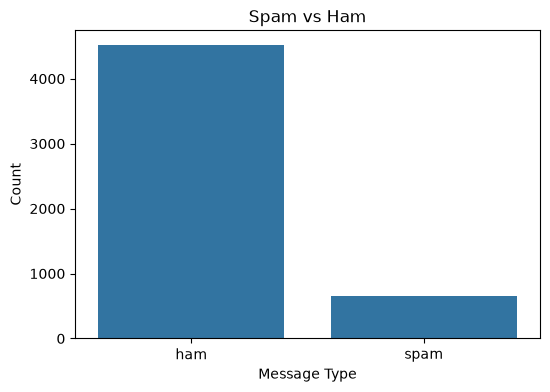

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Label"
)

plt.title("Spam vs Ham")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [18]:
df["Length"] = df["Message"].apply(len)

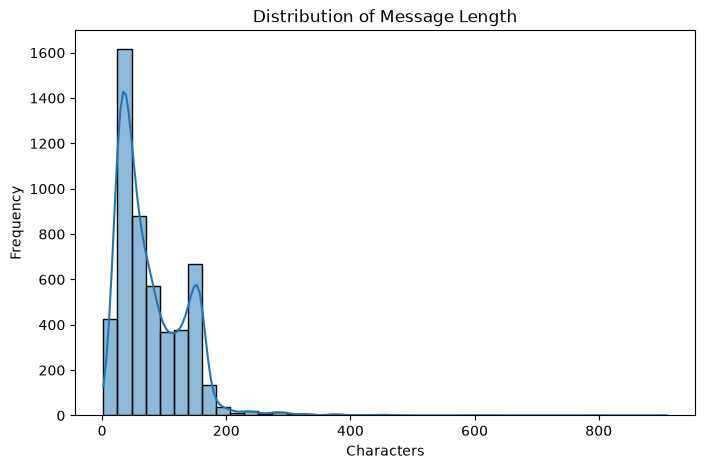

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Length",
    bins=40,
    kde=True
)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

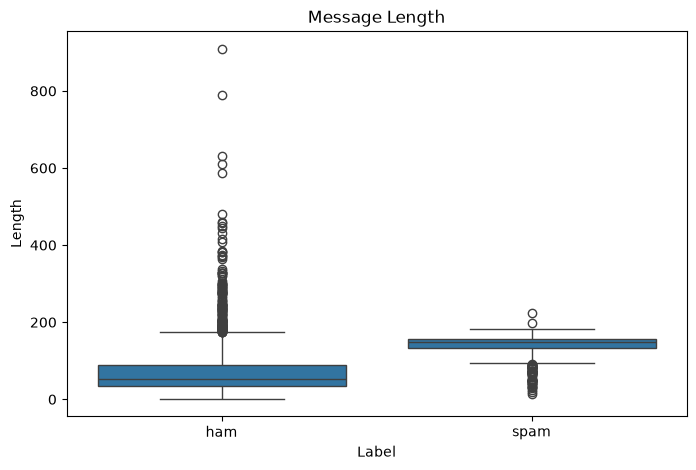

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Label",
    y="Length"
)

plt.title("Message Length")

plt.show()

In [21]:
df["Label"] = df["Label"].map({

    "ham":0,

    "spam":1

})

In [22]:
X = df["Message"]

y = df["Label"]

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"
)

X = vectorizer.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [26]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train,y_train)

nb_pred = nb.predict(X_test)

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [29]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Logistic Regression :",accuracy_score(y_test,lr_pred))

print("Naive Bayes :",accuracy_score(y_test,nb_pred))

print("Decision Tree :",accuracy_score(y_test,dt_pred))

print("Random Forest :",accuracy_score(y_test,rf_pred))

print("SVM :",accuracy_score(y_test,svm_pred))

Logistic Regression : 0.9458413926499033
Naive Bayes : 0.965183752417795
Decision Tree : 0.9671179883945842
Random Forest : 0.9748549323017408
SVM : 0.9777562862669246


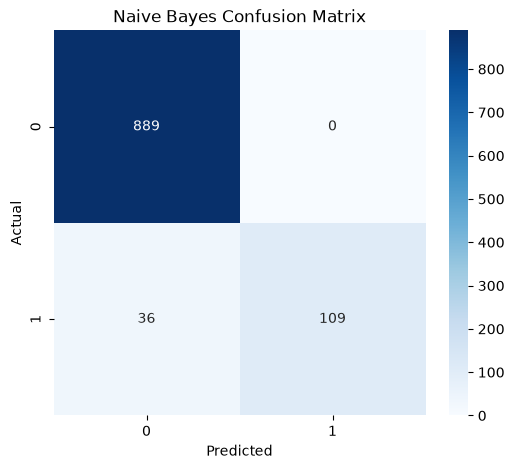

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    nb_pred
))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.75      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



In [33]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Naive Bayes",

        "Decision Tree",

        "Random Forest",

        "SVM"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,nb_pred),

        accuracy_score(y_test,dt_pred),

        accuracy_score(y_test,rf_pred),

        accuracy_score(y_test,svm_pred)

    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.945841
1,Naive Bayes,0.965184
2,Decision Tree,0.967118
3,Random Forest,0.974855
4,SVM,0.977756


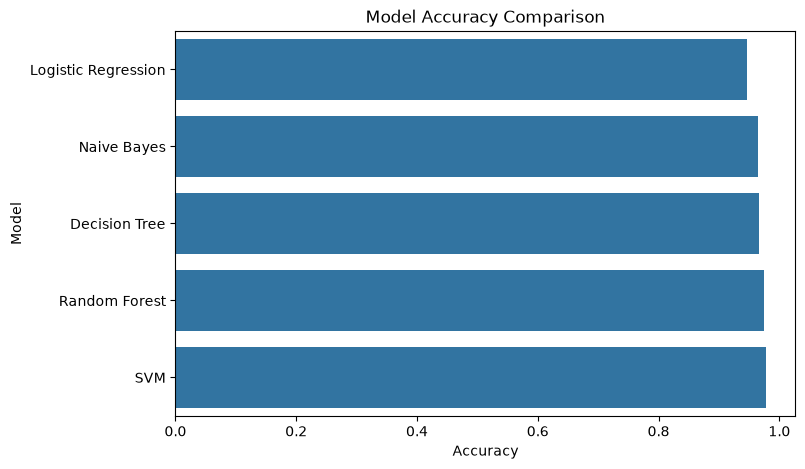

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x="Accuracy",

    y="Model"

)

plt.title("Model Accuracy Comparison")

plt.show()

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(

    nb,

    X,

    y,

    cv=5

)

print(scores)

print("Average Accuracy :",scores.mean())

[0.9729207  0.95841393 0.95938104 0.96518375 0.95934172]
Average Accuracy : 0.9630482285731405
